## 01 — EDA Fundamentals: Quality · Distributions · Correlations

**Dataset:** `ecom_shop.csv.gz` — E-commerce events, January 2021#%% md

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [34]:
PALETTE  = 'muted'
FIG_SIZE = (12, 5)
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.05)
FIGURES_PATH = '../outputs/figures/'

---
### Phase 1 — Data Quality & Ingestion

#### 1.1 Load and parse timestamps

In [4]:
df = pd.read_csv('../data/raw/ecom_shop.csv', parse_dates=['timestamp'])

#### 1.2 Schema overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549020 entries, 0 to 549019
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   timestamp           549020 non-null  datetime64[ns]
 1   user_id             549020 non-null  float64       
 2   event               549020 non-null  object        
 3   category            549020 non-null  object        
 4   country             549020 non-null  object        
 5   source              549020 non-null  object        
 6   is_old_user         549020 non-null  bool          
 7   session_id          549020 non-null  object        
 8   session_number      549020 non-null  int64         
 9   page_location       549020 non-null  object        
 10  page_location_cats  549020 non-null  object        
 11  event_order         549020 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 46.6+ MB


#### 1.4 Duplicate detection

In [6]:
n_dup_rows = df.duplicated().sum()
print(f"Duplicate rows : {n_dup_rows:,}")

Duplicate rows : 0


#### 1.5 Temporal consistency

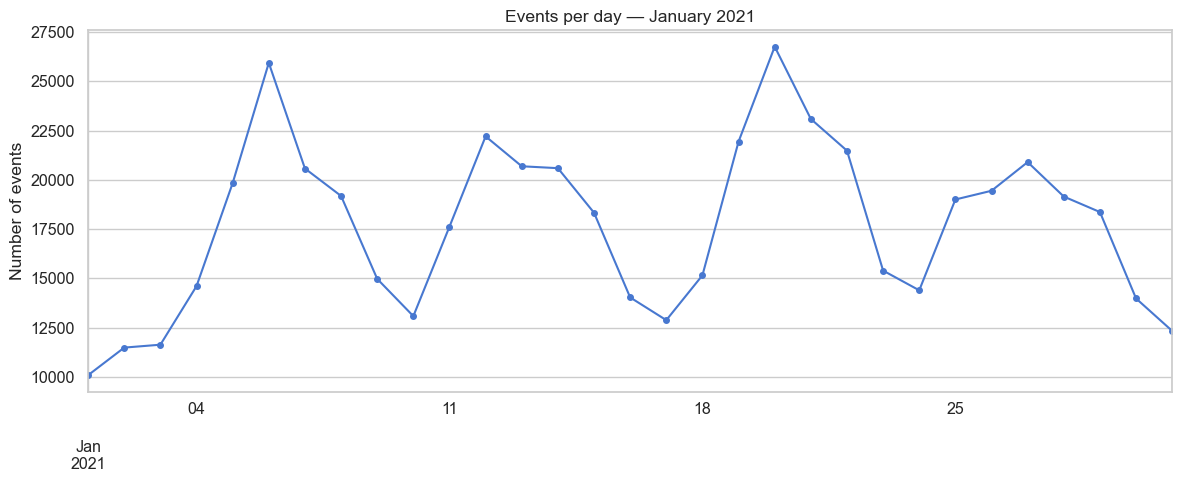

In [9]:
# Events per day
daily_counts = df.resample('D', on='timestamp').size().rename('n_events')

fig, ax = plt.subplots(figsize=FIG_SIZE)
daily_counts.plot(ax=ax, marker='o', linewidth=1.5, markersize=4)
ax.set_title('Events per day — January 2021')
ax.set_ylabel('Number of events')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p1_events_per_day.png', dpi=120)
plt.show()

El volumen diario muestra un patrón semanal consistente con caídas en fin de semana.
Se detecta un pico anómalo 21 enero (~26,500 eventos) que podría reflejar una
campaña de marketing puntual. Este patrón sugiere no-estacionariedad temporal

#### 1.6 Time features

In [12]:
df['hour']       = df['timestamp'].dt.hour
df['dayofweek']  = df['timestamp'].dt.dayofweek   # 0 = Monday
df['dayname']    = df['timestamp'].dt.day_name()
df['date']       = df['timestamp'].dt.date

df[['timestamp','hour','dayofweek','dayname']].head(3)

,timestamp,hour,dayofweek,dayname
0,2021-01-20 11:04:59.887247,11,2,Wednesday
1,2021-01-20 11:04:59.887247,11,2,Wednesday
2,2021-01-20 11:05:05.002377,11,2,Wednesday


---
### Phase 2 — Univariate Distributions & Temporal Patterns

#### 2.1 Distributions of `session_number per user` and `event_order`

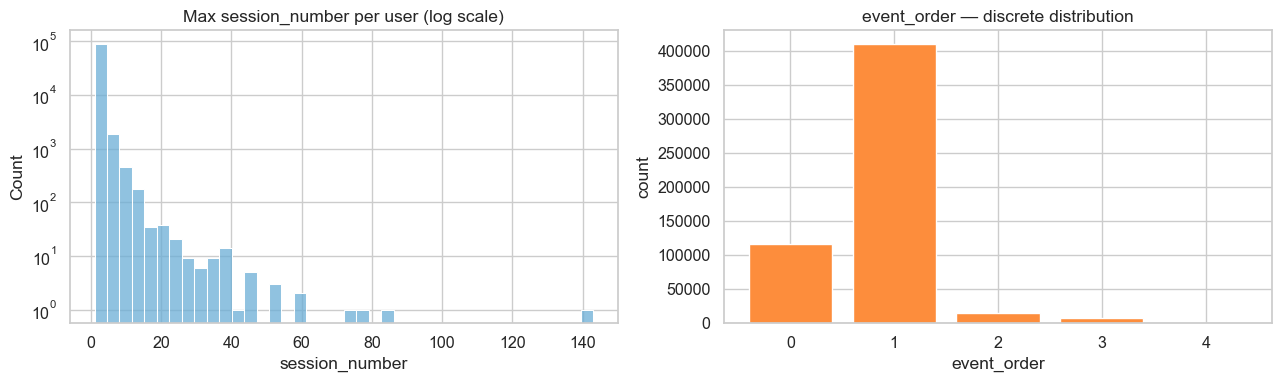

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
s = df.groupby('user_id')['session_number'].max()
sns.histplot(s, bins=40, kde=False, ax=ax, color='#6baed6')
ax.set_yscale('log')
ax.set_title('Max session_number per user (log scale)')
ax.set_xlabel('session_number')

ax = axes[1]
vc = df['event_order'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color='#fd8d3c', edgecolor='white')
ax.set_title('event_order — discrete distribution')
ax.set_xlabel('event_order')
ax.set_ylabel('count')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p2_distributions.png', dpi=120)
plt.show()

`session_number` sigue una distribución de cola larga (power-law), con la mayoría
de usuarios en 1-2 sesiones y una minoría de power users hasta sesión 140.

`event_order` es discreta con valores 0-4

#### 2.2 Categorical distributions — bar charts

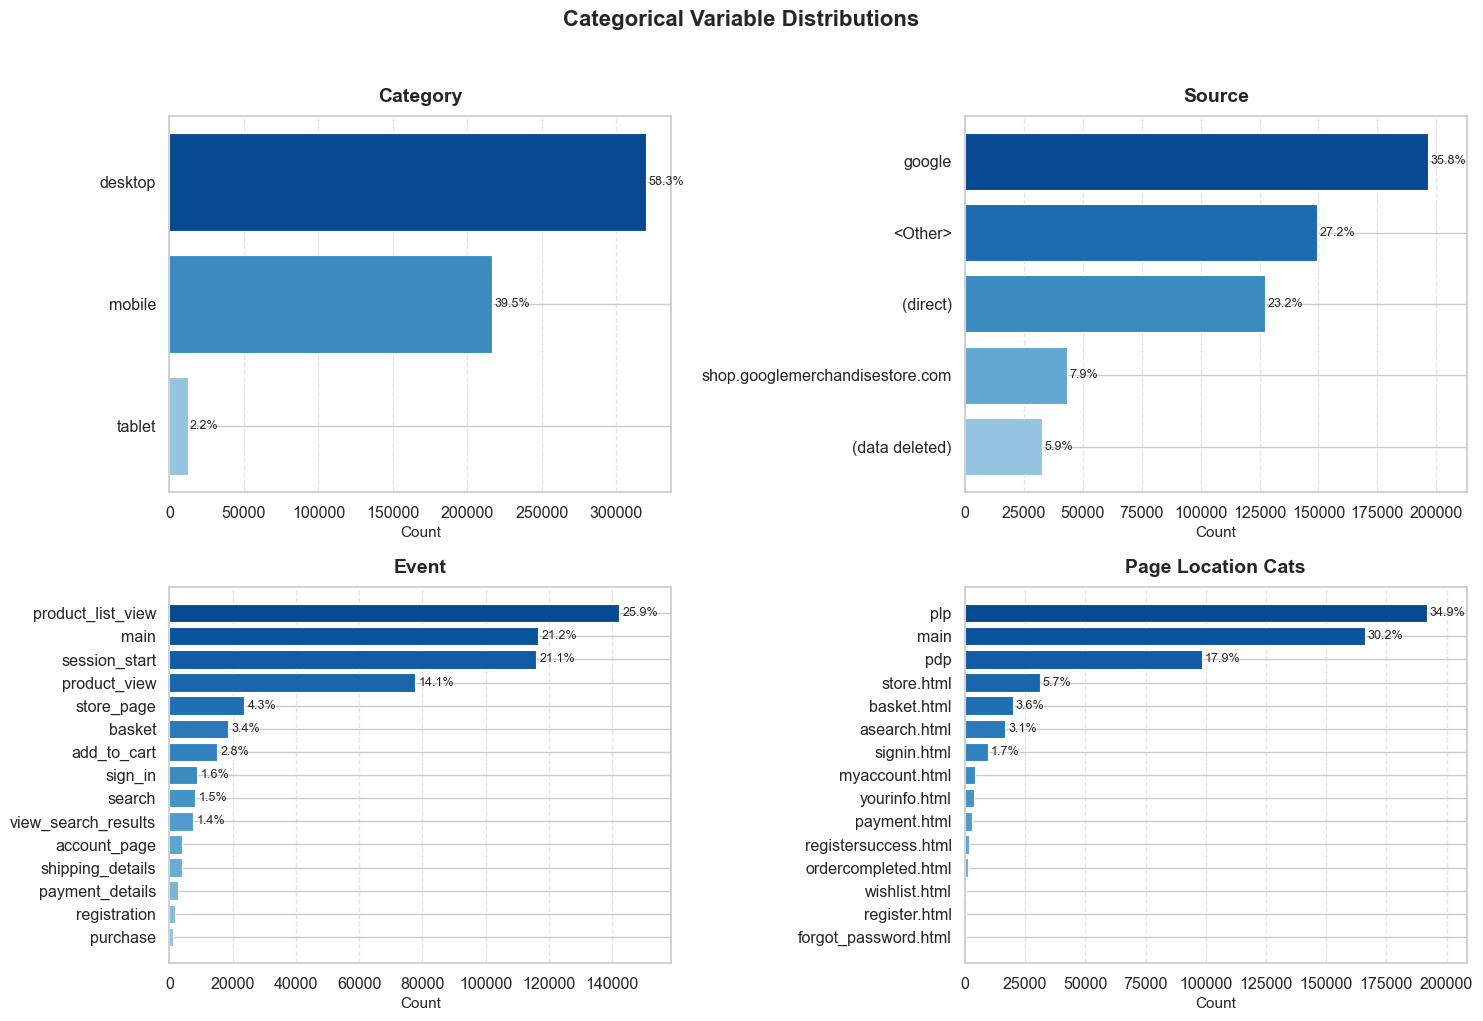

In [37]:
cat_cols = ['category', 'source', 'event', 'page_location_cats']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts().head(15)          # descendente
    vc = vc[::-1]                                 # invertido: ascendente (menor arriba)
    total = len(df)

    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(vc)))

    ax = axes[i]
    ax.barh(vc.index, vc.values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(col.replace('_', ' ').title(), fontsize=14, weight='bold', pad=10)
    ax.set_xlabel('Count', fontsize=11)
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    for j, val in enumerate(vc.values):
        pct = 100 * val / total
        if val > total * 0.01:
            ax.text(val + total * 0.002, j, f'{pct:.1f}%',
                    va='center', fontsize=9, fontweight='medium')

    ax.set_xlim(0, vc.max() + total * 0.03)

plt.suptitle('Categorical Variable Distributions', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p3_cat_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2.3 New vs Old users

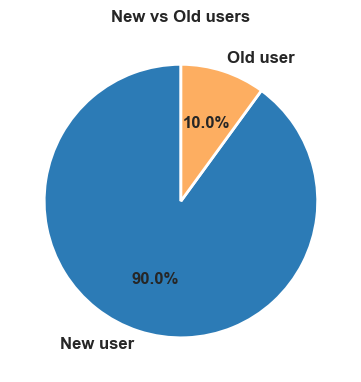

In [38]:
label_map = {True: 'Old user', False: 'New user'}
df['user_type'] = df['is_old_user'].map(label_map)

plt.figure(figsize=(4,4))
df['user_type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2c7bb6', '#fdae61'], startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2},
    textprops={'fontsize':12, 'weight':'bold'}
)
plt.ylabel('')
plt.title('New vs Old users', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p4_pie_new_old.png', dpi=150)
plt.show()

#### 2.5 Heatmap — events by hour of day × day of week

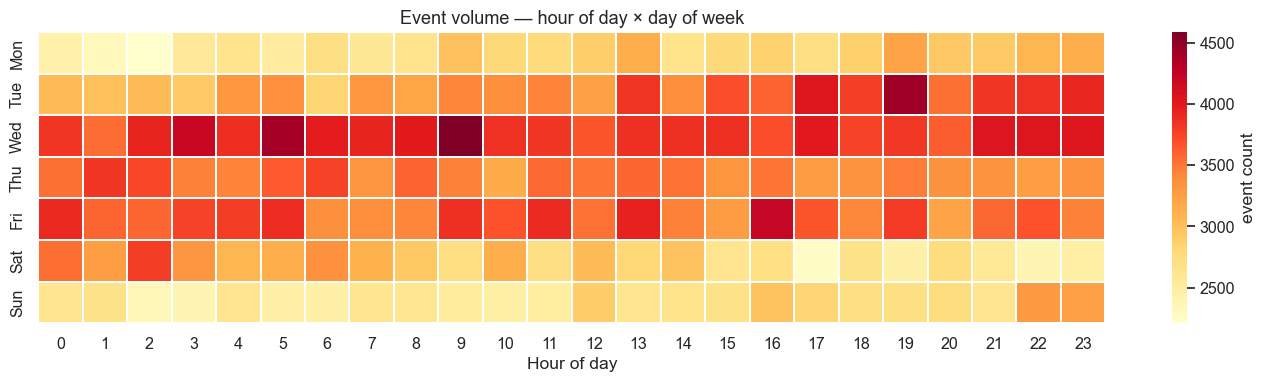

In [39]:
pivot = (df.groupby(['dayofweek', 'hour'])
           .size()
           .unstack(fill_value=0))

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot.index = day_labels

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'event count'})
ax.set_title('Event volume — hour of day × day of week', fontsize=13)
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p5_heatmap_hour_dow.png', dpi=120)
plt.show()

---
### Phase 3 — Multivariate Analysis

#### 3.1 Correlation matrix

In [30]:
user_features = df.groupby('user_id').agg(
    n_sessions=('session_id', 'nunique'),
    n_events=('event', 'count'),
    is_old_user=('is_old_user', 'first'),
    has_purchase=('event', lambda x: (x == 'purchase').any())
).reset_index()

user_features['avg_session_length'] = user_features['n_events'] / user_features['n_sessions']

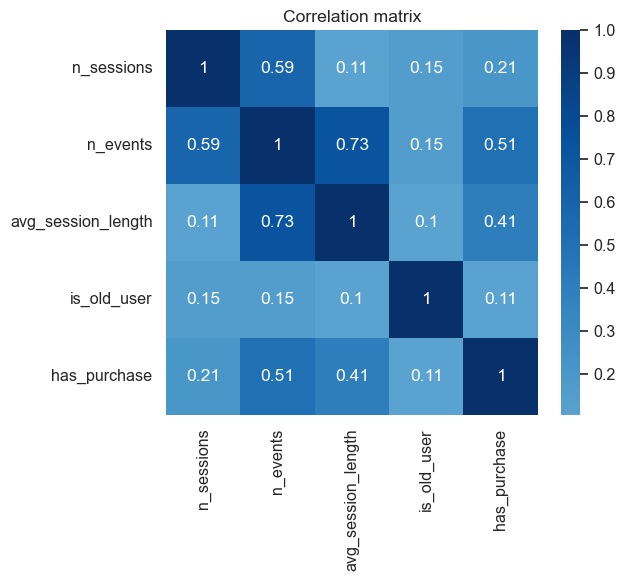

In [40]:
corr_matrix = user_features[['n_sessions', 'n_events', 'avg_session_length', 'is_old_user', 'has_purchase']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', center=0)
plt.title('Correlation matrix')
plt.savefig(f'{FIGURES_PATH}corr_matrix.png', dpi=120)
plt.show()

La matriz revela que la profundidad de sesión (`n_events`, `avg_session_length`) está
fuertemente correlacionada (r=0.73), mientras que `purchase` depende más del
comportamiento en sesión que de la antigüedad del usuario (r=0.11).

#### 3.2 Events by device

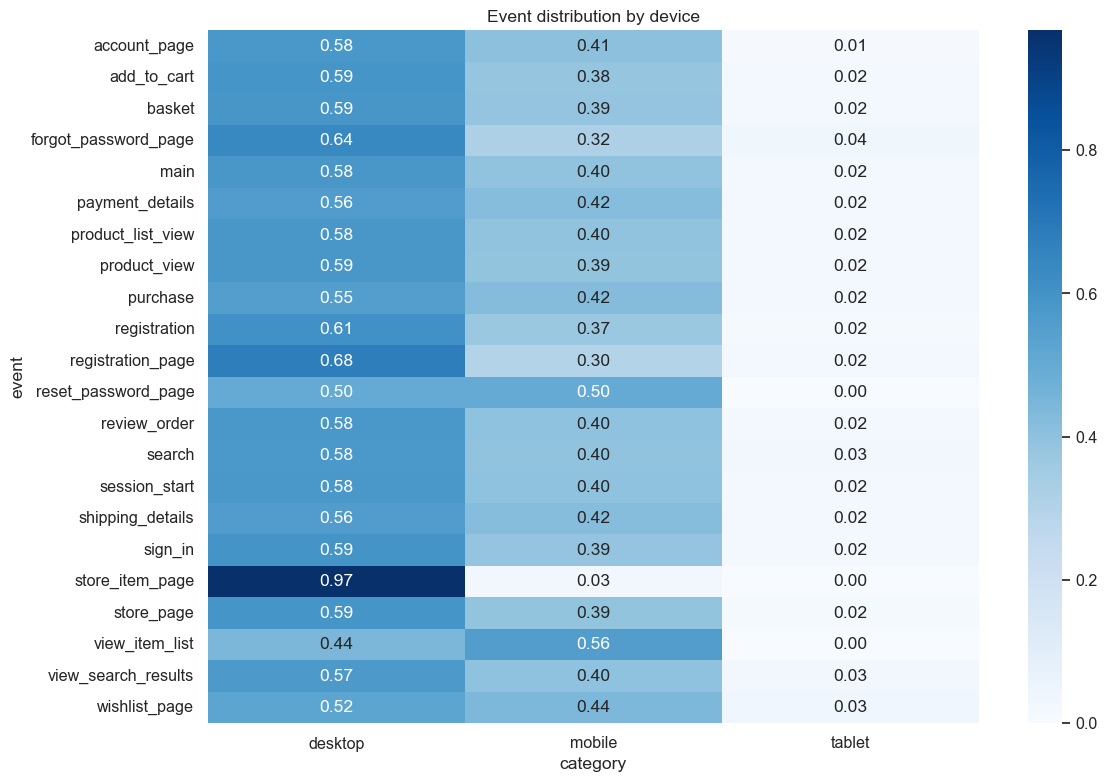

In [32]:
event_device = pd.crosstab(df['event'], df['category'], normalize='index')
plt.figure(figsize=(12,8))
sns.heatmap(event_device, annot=True, cmap='Blues', fmt='.2f')
plt.title('Event distribution by device')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}event_device_heatmap.png')
plt.show()